# Stacking Classification

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import joblib

sns.set_style('whitegrid')

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import (classification_report, accuracy_score, precision_score, 
                             recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)

## Ler Dados

In [2]:
df_leads = pd.read_csv("./dataset/leads.csv")

In [3]:
df_leads.info()

<class 'pandas.DataFrame'>
RangeIndex: 9074 entries, 0 to 9073
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Lead Origin                             9074 non-null   str    
 1   Lead Source                             9074 non-null   str    
 2   Do Not Email                            9074 non-null   int64  
 3   Do Not Call                             9074 non-null   int64  
 4   Converted                               9074 non-null   int64  
 5   TotalVisits                             9074 non-null   float64
 6   Total Time Spent on Website             9074 non-null   int64  
 7   Page Views Per Visit                    9074 non-null   float64
 8   Last Activity                           9074 non-null   str    
 9   Search                                  9074 non-null   int64  
 10  Newspaper Article                       9074 non-null   int64  
 11  X 

In [4]:
df_leads.head(10)

,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Search,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,0,0,0,0.0,0,0.0,Page Visited on Website,0,0,0,0,0,0,0,Modified
1,API,Organic Search,0,0,0,5.0,674,2.5,Email Opened,0,0,0,0,0,0,0,Email Opened
2,Landing Page Submission,Direct Traffic,0,0,1,2.0,1532,2.0,Email Opened,0,0,0,0,0,0,1,Email Opened
3,Landing Page Submission,Direct Traffic,0,0,0,1.0,305,1.0,Unreachable,0,0,0,0,0,0,0,Modified
4,Landing Page Submission,Google,0,0,1,2.0,1428,1.0,Converted to Lead,0,0,0,0,0,0,0,Modified
5,API,Olark Chat,0,0,0,0.0,0,0.0,Olark Chat Conversation,0,0,0,0,0,0,0,Modified
6,Landing Page Submission,Google,0,0,1,2.0,1640,2.0,Email Opened,0,0,0,0,0,0,0,Modified
7,API,Olark Chat,0,0,0,0.0,0,0.0,Olark Chat Conversation,0,0,0,0,0,0,0,Modified
8,Landing Page Submission,Direct Traffic,0,0,0,2.0,71,2.0,Email Opened,0,0,0,0,0,0,1,Email Opened
9,API,Google,0,0,0,4.0,58,4.0,Email Opened,0,0,0,0,0,0,0,Email Opened


## Preparação dos Dados

In [5]:
preprocessor: ColumnTransformer = joblib.load("preprocessor.pkl")

In [6]:
X = df_leads.drop(columns=['Converted'])
y = df_leads['Converted']

numeric_features = X.select_dtypes('number').columns
cat_features = X.select_dtypes('str').columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=51)

X_train = preprocessor.fit_transform(X_train).toarray()
X_test = preprocessor.transform(X_test).toarray()

In [7]:
X_test.shape

(1815, 68)

In [8]:
X_train.shape

(7259, 68)

## Treinamento do Modelo
- estimadores organizados no formato [('model_name', Model( )), ...]

In [9]:
# Meta-Modelo
lr_model = LogisticRegression(random_state=51)

# Modelos Base
tree_model = DecisionTreeClassifier(random_state=51)
svc_model = SVC(kernel='linear', random_state=51)
sgd_model = SGDClassifier(penalty='elasticnet', random_state=51)

In [10]:
stacking_model = StackingClassifier(
  estimators=[
    ("tree", tree_model),
    ('svc', svc_model),
    ('sgd', sgd_model),
  ],
  final_estimator=lr_model,
  # False = Vanilla (treina meta-modelo com dados dos estimadores)
  # True = Blending (treina meta-modelo com dados originais e com dados dos estimadores)
  passthrough=False,
)

In [11]:
stacking_model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('tree', ...), ('svc', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=51)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[DecisionTreeC...ndom_state=51), SVC(kernel='l...ndom_state=51), SGDClassifier...ndom_state=51)]"
final_estimator_ final_estimator_: estimatorThe classifier fit on the output of `estimators_` and responsible forfinal predictions.,LogisticRegression,LogisticRegre...ndom_state=51)


## Análise de Métricas

In [12]:
y_pred = stacking_model.predict(X_test)

In [13]:
accuracy = accuracy_score(y_pred=y_pred, y_true=y_test)
precision = precision_score(y_pred=y_pred, y_true=y_test)
recall = recall_score(y_pred=y_pred, y_true=y_test)
f1 = f1_score(y_pred=y_pred, y_true=y_test)
class_report = classification_report(y_pred=y_pred, y_true=y_test, digits=4)

In [14]:
print(f"Acurácia: {accuracy}")
print(f"Precisão: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

Acurácia: 0.8
Precisão: 0.74481658692185
Recall: 0.6970149253731344
F1-Score: 0.7201233616037008


In [15]:
print(class_report)

              precision    recall  f1-score   support

           0     0.8291    0.8603    0.8444      1145
           1     0.7448    0.6970    0.7201       670

    accuracy                         0.8000      1815
   macro avg     0.7870    0.7786    0.7823      1815
weighted avg     0.7980    0.8000    0.7985      1815



### Matriz de Confusão

Text(0.5, 1.0, 'Matriz de Confusão')

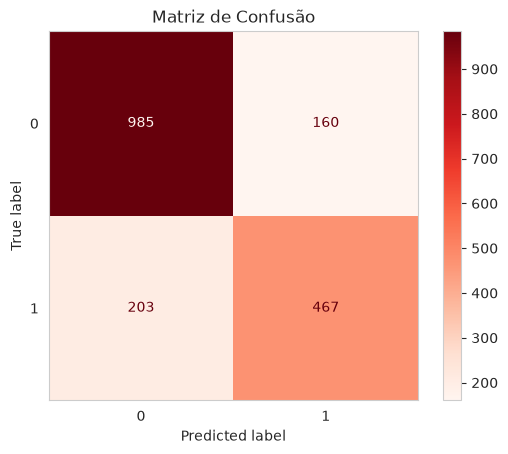

In [16]:
conf_matrix = confusion_matrix(y_pred=y_pred, y_true=y_test)
cmd = ConfusionMatrixDisplay(conf_matrix)
cmd.plot(
  cmap='Reds'
)
plt.grid(visible=False)
plt.title("Matriz de Confusão")

## Importância das Features

In [17]:
importances = list()
for estimator in stacking_model.estimators_:
    # Modelos lineares possuem coeficientes
    if hasattr(estimator, 'coef_'):
        importances.append(np.abs(estimator.coef_[0]))

    # Modelos baseados em árvores
    elif hasattr(estimator, 'feature_importances_'):
        importances.append(np.abs(estimator.feature_importances_))
    else:
        print(f"Não foi possível calcular a importância para {type(estimador).__name__}")

In [18]:
importances_mean = np.mean(importances, axis=0)

In [22]:
feature_names = (numeric_features.tolist() + list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features.tolist())))

In [27]:
df_features = pd.DataFrame({ 'feature': feature_names, 'importance': importances_mean })
df_features.sort_values(by='importance', ascending=True, inplace=True)

In [30]:
fig = px.bar(
  df_features,
  x='importance',
  y='feature',
  orientation='h',
  title='Importância das Features (Coeficientes Absolutos)'
)

fig.update_layout(width=1280, height=1000)

## Propriedades do Modelo

### Mostrar Evidências do Modelo